In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : 12}

plt.rc('font', **font)
plot_fs = 12

plt.rc('font', family='serif', serif='Times')
plt.rc('text', usetex=True)
plt.rc('xtick', labelsize=9)
plt.rc('ytick', labelsize=9)
plt.rc('axes', labelsize=10)
mpl.rcParams['lines.dashed_pattern'] = [2, 2]
mpl.rcParams['lines.linewidth'] = 1.0

import pathlib
cur_dir = pathlib.Path().cwd()
parent_dir = cur_dir.parent

import sys
print(sys.version)
sys.path.append('../')

from models.powertrain.bounded_powertrain import Bounded_powertrain
from models.kinematic.ideal_diff_drive import Ideal_diff_drive
from models.learning.blr_slip import SlipBayesianLinearRegression, FullBodySlipBayesianLinearRegression
from models.learning.blr_slip_acceleration import SlipAccelerationBayesianLinearRegression, FullBodySlipAccelerationBayesianLinearRegression
from models.kinematic.ICR_based import *
from models.kinematic.Perturbed_unicycle import *
from models.kinematic.enhanced_kinematic import *
from NicolasSamson.script.extractors import * 
from util.transform_algebra import *
from util.util_func import *
from data_utils.dataset_parser import *

3.8.19 (default, Apr  6 2024, 17:58:10) 
[GCC 11.4.0]


Import le dataset

In [2]:
path_2_dataset = '../data/ral2023_dataset/warthog_wheels/ice/acceleration_dataset.pkl'

df_acceleration = pd.read_pickle(path_2_dataset)

print_column_unique_column(df_acceleration)

['init_icp_x' 'init_icp_y' 'init_icp_z' 'init_icp_roll' 'init_icp_pitch'
 'init_icp_yaw' 'calib_step' 'cmd_left' 'cmd_right' 'left_wheel_vel'
 'right_wheel_vel' 'icp_x' 'icp_y' 'icp_z' 'icp_roll' 'icp_pitch'
 'icp_yaw' 'imu_yaw' 'icp_vx' 'icp_vy' 'icp_omega' 'steady_state_mask'
 'transitory_state_mask' 'imu_acceleration_x' 'imu_acceleration_y'
 'imu_acceleration_z' 'gt_icp_x' 'gt_icp_y' 'gt_icp_z' 'gt_icp_roll'
 'gt_icp_pitch' 'gt_icp_yaw' 'transitory_vel_left' 'transitory_vel_right'
 'idd_vel_x' 'idd_vel_y' 'idd_vel_yaw' 'icp_interpolated_x'
 'icp_interpolated_y' 'icp_interpolated_yaw'
 'icp_corrected_interpolated_x' 'icp_corrected_interpolated_y' 'icp_vel_x'
 'icp_vel_y' 'icp_vel_yaw' 'body_vel_disturption_x'
 'body_vel_disturption_y' 'body_vel_disturption_yaw' 'idd_acceleration_x'
 'idd_acceleration_y' 'idd_acceleration_yaw' 'icp_acceleration_x'
 'icp_acceleration_y' 'icp_acceleration_yaw']


Plot the 3D graph showing the evolution of the command and the ground truth

Text(0.5, 0, 'X speed [m/s]')

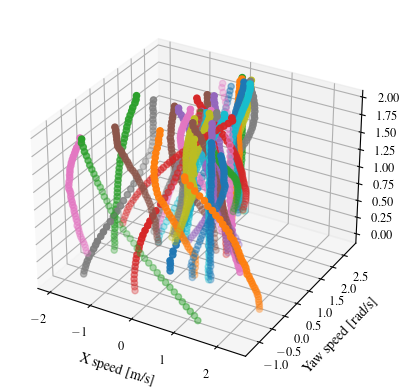

In [3]:
print_column_unique_column


icep_vel_x = column_type_extractor(df_acceleration, 'icp_vel_x',verbose=False)
icep_vel_yaw = column_type_extractor(df_acceleration, 'icp_vel_yaw',verbose=False)
time = create_time_axe(0.05,icep_vel_x.shape[1])


fig = plt.figure(figsize=plt.figaspect(0.5))
axs = fig.add_subplot(1, 1, 1, projection='3d')

for i in range(icep_vel_x.shape[1]):
    axs.scatter(icep_vel_x[i,:],icep_vel_yaw[i,:],time)

axs.set_ylabel("Yaw speed [rad/s]")
axs.set_xlabel("X speed [m/s]")



Calculate the body command

Text(0.5, 0, 'X speed [m/s]')

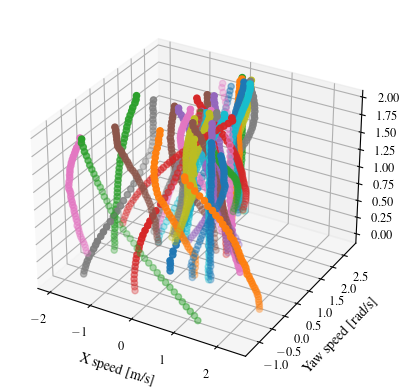

In [ ]:
print_column_unique_column


icep_vel_x = column_type_extractor(df_acceleration, 'icp_vel_x',verbose=False)
icep_vel_yaw = column_type_extractor(df_acceleration, 'icp_vel_yaw',verbose=False)
time = create_time_axe(0.05,icep_vel_x.shape[1])


fig = plt.figure(figsize=plt.figaspect(0.5))
axs = fig.add_subplot(1, 1, 1, projection='3d')

for i in range(icep_vel_x.shape[1]):
    axs.scatter(icep_vel_x[i,:],icep_vel_yaw[i,:],time)

axs.set_ylabel("Yaw speed [rad/s]")
axs.set_xlabel("X speed [m/s]")



In [51]:

# Steady state keeping
df_steady_state = df_acceleration[df_acceleration['steady_state_mask'] == 1]
print(df_steady_state.shape)


# Remove the first window
df_last_window = df_steady_state.drop_duplicates(subset=['steady_state_mask','calib_step'],keep='last')
#print(df_last_window.shape)

print(df_last_window.shape)


cmd_left = np.mean(column_type_extractor(df_group_by_mean, 'cmd_l',verbose=False),axis=1)
cmd_right = np.mean(column_type_extractor(df_group_by_mean, 'cmd_r',verbose=False),axis=1)
cmd_vel = np.vstack((cmd_left,cmd_right))



body_vel = compute_body_vel_IDD(cmd_vel , robot='warthog-wheel')



(394, 1458)
(197, 1458)
(2, 197)
[[-1.54973987e-01  3.00224119e+00 -1.80096420e-01 -7.51801516e-01
   7.66777696e-01 -1.53785021e+00  9.06920401e-01 -2.27386151e+00
  -2.13447254e+00 -6.20191931e-01  2.88349670e+00  1.10056269e+00
  -1.80286319e+00 -1.30982936e+00 -3.01081985e+00 -2.19523280e+00
   5.14556777e-01  5.23707158e-01 -1.21602221e+00  1.73159097e-01
  -2.86431709e+00  2.50415656e-01  6.36326408e-01 -2.68097660e-02
  -3.46839752e-01 -4.75759352e-01  5.87954856e-01 -1.72424271e+00
  -1.39690886e+00 -2.14117944e+00 -1.65602187e+00 -2.70121075e+00
  -3.34077157e-01  1.01525928e+00 -9.85961848e-01 -1.28924845e+00
  -2.62186534e-01  2.40588505e-01 -1.21079286e+00 -3.54581446e-01
  -6.35304526e-01  1.52763280e-01  6.62158312e-01 -1.55858173e+00
   2.04271601e+00  3.64697677e-01 -8.91464740e-01  1.36977333e+00
   7.13680714e-01 -2.63061505e+00  2.48620617e+00  9.80475563e-01
  -3.15224579e-01  1.12477725e+00  2.94258308e+00 -3.58022584e+00
  -1.36835532e-02  1.50073364e+00 -7.841752

Plot the command:

In [ ]:


'cmd_left' 'cmd_right'